# Feature Engineering 

- Aggeration of the dataset which transform the transaction data we got into customer base dataset 

In [21]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 

In [22]:
cleaned_df = pd.read_csv("C:\\Desktop\\Online retail UnsML k-mean analysis\\notebook\\cleaned_online_retail.csv",dtype={"StockCode":"str"})

In [23]:
cleaned_df["Sales"] = cleaned_df["Quantity"] * cleaned_df["Price"]

In [24]:
cleaned_df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Sales
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
2,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0
3,489434,22064,PINK DOUGHNUT TRINKET POT,24,2009-12-01 07:45:00,1.65,13085.0,United Kingdom,39.6
4,489434,21871,SAVE THE PLANET MUG,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [25]:
agg_cleaned_df = cleaned_df.groupby("Customer ID").agg(
    Country = ("Country", "first"),
    Total_sales = ("Sales", "sum"),
    Frequency = ("Invoice","nunique"), # nunique = number of unique number 
    LastInvoiceDate = ("InvoiceDate", "max")
).reset_index() # reset_index() is use to reset the customer ID to normal column as it currently set as index 

In [26]:
agg_cleaned_df["Reference_date"] = agg_cleaned_df["LastInvoiceDate"].max()  # Anchor point for recency date 

In [ ]:
# Convert both string column into datetime data type
agg_cleaned_df["Reference_date"] = pd.to_datetime(agg_cleaned_df["Reference_date"],errors="coerce")
agg_cleaned_df["LastInvoiceDate"] = pd.to_datetime(agg_cleaned_df["LastInvoiceDate"],errors="coerce")

# Define the recency column
agg_cleaned_df["Recency"] = (agg_cleaned_df["Reference_date"] - agg_cleaned_df["LastInvoiceDate"]).dt.days

In [33]:
agg_cleaned_df.info()
agg_cleaned_df.head(5)

<class 'pandas.DataFrame'>
RangeIndex: 4248 entries, 0 to 4247
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      4248 non-null   float64       
 1   Country          4248 non-null   str           
 2   Total_sales      4248 non-null   float64       
 3   Frequency        4248 non-null   int64         
 4   LastInvoiceDate  4248 non-null   datetime64[us]
 5   Reference_date   4248 non-null   datetime64[us]
 6   Recency          4248 non-null   int64         
dtypes: datetime64[us](2), float64(2), int64(2), str(1)
memory usage: 232.4 KB


,Customer ID,Country,Total_sales,Frequency,LastInvoiceDate,Reference_date,Recency
0,12346.0,United Kingdom,144.02,2,2010-06-28 13:53:00,2010-12-09 20:01:00,164
1,12347.0,Iceland,966.87,2,2010-12-07 14:57:00,2010-12-09 20:01:00,2
2,12348.0,Finland,221.16,1,2010-09-27 14:59:00,2010-12-09 20:01:00,73
3,12349.0,Italy,1946.64,2,2010-10-28 08:23:00,2010-12-09 20:01:00,42
4,12351.0,Unspecified,300.93,1,2010-11-29 15:23:00,2010-12-09 20:01:00,10


# Identify Outlier and distribution 

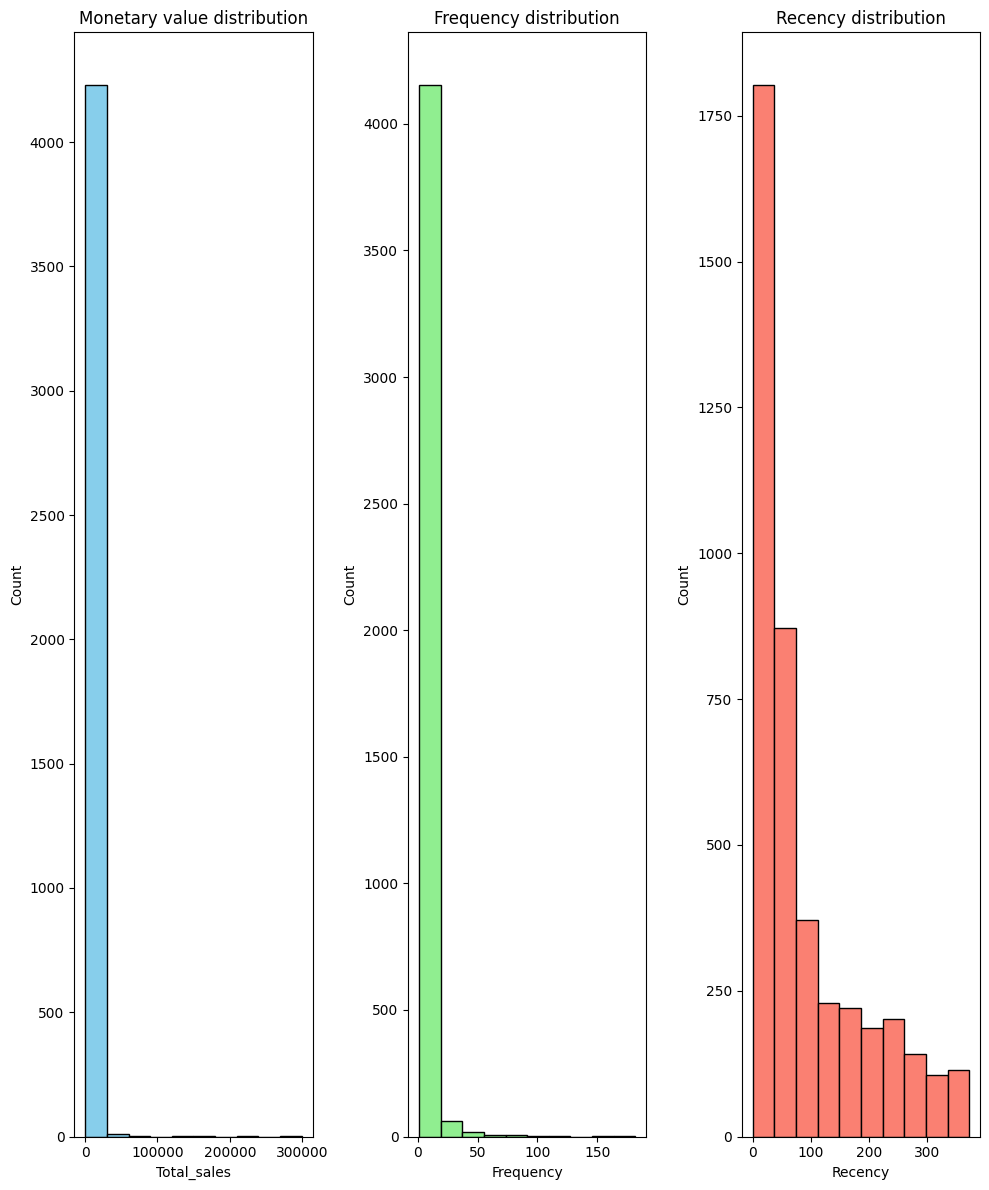

In [ ]:
# Identify the distribution with histogram visualization

plt.figure(figsize=(10,12))

plt.subplot(1,3,1)
plt.hist(agg_cleaned_df["Total_sales"], bins=10,color="skyblue",edgecolor="black")
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")
plt.ylabel("Count")

plt.subplot(1,3,2)
plt.hist(agg_cleaned_df["Frequency"], bins=10,color="lightgreen",edgecolor="black")
plt.title("Frequency distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

plt.subplot(1,3,3)
plt.hist(agg_cleaned_df["Recency"], bins=10,color="salmon",edgecolor="black")
plt.title("Recency distribution")
plt.xlabel("Recency")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

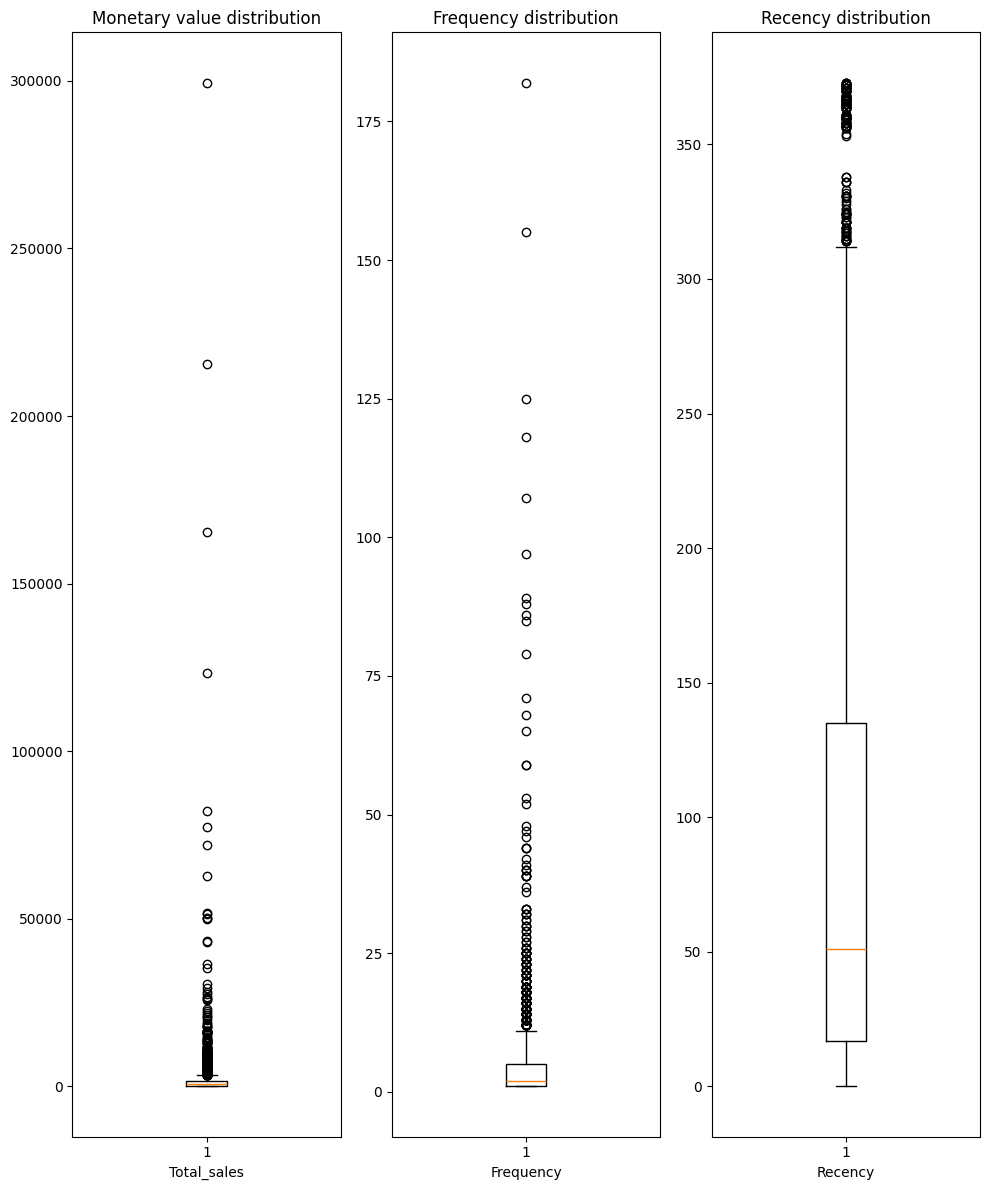

In [41]:
# Identify the outlier with boxplot

plt.figure(figsize=(10,12))

plt.subplot(1,3,1)
plt.boxplot(agg_cleaned_df["Total_sales"])
plt.title("Monetary value distribution")
plt.xlabel("Total_sales")


plt.subplot(1,3,2)
plt.boxplot(agg_cleaned_df["Frequency"])
plt.title("Frequency distribution")
plt.xlabel("Frequency")


plt.subplot(1,3,3)
plt.boxplot(agg_cleaned_df["Recency"])
plt.title("Recency distribution")
plt.xlabel("Recency")


plt.tight_layout()
plt.show()